This program is used to calculate the curvature of an airfoil

Maximum curvature: 15.068497
Upper-surface regions with curvature < 0.2:
  Region 1: 6.517788


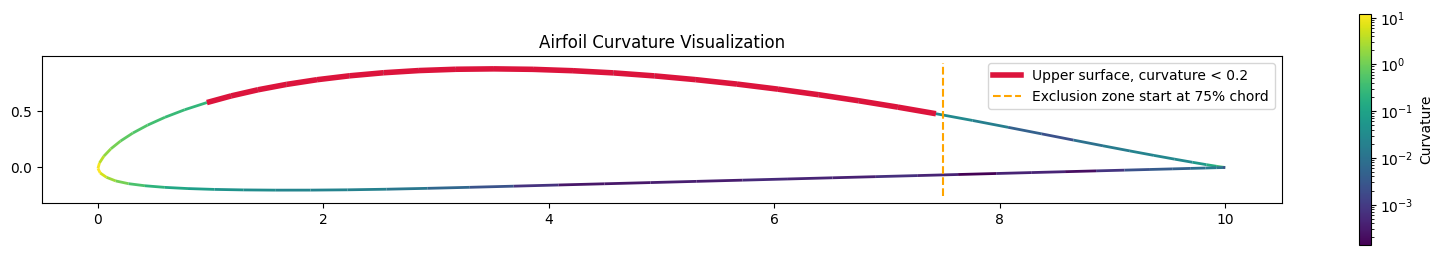

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as colors

airfoil = pd.read_csv('airfoils/s7055.csv', header=0, names=['x', 'y'])

# Normalize the airfoil coordinates to the range [0, 1]
chord_length = 10.0 # Any units
airfoil = airfoil / np.max(airfoil['x']) * chord_length
curvature_threshold = 0.2 # Same units as chord length
rear_exclusion = 0.25 # Exclude the last X% of the airfoil from the panel region


# Calculate the curvature at each point along the airfoil
curvature = np.zeros(len(airfoil['x']))
for i in range(1, len(airfoil) - 1):
    x0, y0 = airfoil.iloc[i - 1]
    x1, y1 = airfoil.iloc[i]
    x2, y2 = airfoil.iloc[i + 1]

    ab = np.array([x1 - x0, y1 - y0, 0])
    ac = np.array([x2 - x0, y2 - y0, 0])
    bc = np.array([x2 - x1, y2 - y1, 0])

    # Calculate the curvature using the formula k = 2 ||AB X AC|| / (||AB|| * ||AC|| * ||BC||)
    curvature[i] = 2 * np.linalg.norm(np.cross(ab, ac)) / (np.linalg.norm(ab) * np.linalg.norm(ac) * np.linalg.norm(bc))

# Build one line segment per pair of neighboring airfoil points.
points = airfoil[['x', 'y']].to_numpy().reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
segment_curvature = (curvature[:-1] + curvature[1:]) / 2
segment_lengths = np.linalg.norm(segments[:, 1] - segments[:, 0], axis=1)

# Set the threshold used to identify low-curvature regions.
below_threshold = segment_curvature < curvature_threshold
past_cutoff = points[:-1, 0, 0] >= (1 - rear_exclusion) * chord_length

below_threshold = np.logical_and(below_threshold, ~past_cutoff)

# Find contiguous runs of segments below the threshold and calculate their lengths.
all_regions = []
region_start = None
for segment_index, is_below_threshold in enumerate(np.append(below_threshold, False)):
    if is_below_threshold and region_start is None:
        region_start = segment_index
    elif not is_below_threshold and region_start is not None:
        region_end = segment_index
        region_length = segment_lengths[region_start:region_end].sum()
        all_regions.append((region_start, region_end, region_length))
        region_start = None

# Keep only regions on the upper surface; lower-surface regions are ignored.
regions = [
    region for region in all_regions
    if np.mean(points[region[0]:region[1] + 1, 0, 1]) >= 0
]

print(f'Maximum curvature: {curvature.max():.6f}')
print(f'Upper-surface regions with curvature < {curvature_threshold}:')
for region_number, (_, _, region_length) in enumerate(regions, start=1):
    print(f'  Region {region_number}: {region_length:.6f}')

# Plot the airfoil, colored according to curvature.
fig, ax = plt.subplots(figsize=(20, 3))
norm = colors.LogNorm(vmin=segment_curvature.min(), vmax=segment_curvature.max())
line = LineCollection(segments, cmap='viridis', norm=norm, linewidth=2)
line.set_array(segment_curvature)
ax.add_collection(line)

# Mark every continuous upper-surface region below the threshold in crimson.
for region_start, region_end, _ in regions:
    marked_region = LineCollection(
        segments[region_start:region_end], colors='crimson', linewidth=4
    )
    ax.add_collection(marked_region)

ax.autoscale()
ax.set_aspect('equal')
fig.colorbar(line, ax=ax, label='Curvature')
ax.plot([], [], color='crimson', linewidth=4, label=f'Upper surface, curvature < {curvature_threshold}')
ax.vlines(x=(1 - rear_exclusion) * chord_length, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='orange', linestyle='--', label=f'Exclusion zone start at {1 - rear_exclusion:.0%} chord')
ax.set_title('Airfoil Curvature Visualization')
ax.legend(loc='upper right')
plt.show()
